### What is Pandas

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.

https://pandas.pydata.org/about/index.html


### Pandas Series

A Pandas Series is like a column in a table. It is a 1-D array holding data of any type.

A Pandas Series is a one-dimensional labeled array capable of storing elements of the same or different data types. Each element is associated with an index (label).


### Importing Pandas


In [192]:
import numpy as np
import pandas as pd

### Series from lists


In [ ]:
# string
country = ["India", "Pakistan", "USA", "Nepal", "Srilanka"]
print(country)
print(pd.Series(country))  # index(by default by pandas) and values
# and pandas calls string as object why ? because string is a sequence of characters and pandas treats it as an object data type.
#
# object data type can hold any kind of data, it can hold string, integer, float, etc.
# so when we create a series with string data, pandas treats it as an object data type
# and when we create a series with integer data, pandas treats it as an integer data type
# and when we create a series with float data, pandas treats it as a float data type

['India', 'Pakistan', 'USA', 'Nepal', 'Srilanka']
0       India
1    Pakistan
2         USA
3       Nepal
4    Srilanka
dtype: object


In [ ]:
# integers
runs = [13, 24, 56, 78, 15]

runs_ser = pd.Series(
    runs, dtype="int32"
)  # we can specify the data type of the series and it will convert the data to that data type if possible
print(runs_ser)

### Converting 15.3 to int32 would lose the decimal part, so Pandas raises an error instead of doing it implicitly.

0    13
1    24
2    56
3    78
4    15
dtype: int32


In [ ]:
# custom index
marks = [67, 57, 89, 100]
subjects = ["maths", "english", "science", "hindi"]

pd.Series(marks, index=subjects)

maths       67
english     57
science     89
hindi      100
dtype: int64

In [ ]:
# setting a name
Anish_marks = pd.Series(marks, index=subjects, name="Anish ke marks")
Anish_marks

maths       67
english     57
science     89
hindi      100
Name: Anish ke marks, dtype: int64

### Series from dict


In [ ]:
marks = {"maths": 67, "english": 57, "science": 89, "hindi": 100}

marks_series = pd.Series(marks, name="Anish ke marks")
marks_series

maths       67
english     57
science     89
hindi      100
Name: Anish ke marks, dtype: int64

### Series Attributes


In [198]:
# size :  gives the number of elements in the series
marks_series.size

4

In [199]:
# dtype : gives the data type of the series
marks_series.dtype

dtype('int64')

In [200]:
# name : gives the name of the series
marks_series.name

'Anish ke marks'

In [ ]:
# is_unique : gives True if all the elements in the series are unique, False otherwise
marks_series.is_unique

pd.Series([1, 1, 2, 3, 4, 5]).is_unique

False

In [202]:
# index :  gives the index of the series
marks_series.index

Index(['maths', 'english', 'science', 'hindi'], dtype='object')

In [ ]:
print(runs_ser.index, type(runs_ser.index))  # used for indexing and slicing the series


print(runs_ser.items())  # returns an iterator of (index, value) pairs

# iteration over the series
for index, value in runs_ser.items():
    print(f"Index: {index}, Value: {value}")

RangeIndex(start=0, stop=5, step=1) <class 'pandas.core.indexes.range.RangeIndex'>
Index: 0, Value: 13
Index: 1, Value: 24
Index: 2, Value: 56
Index: 3, Value: 78
Index: 4, Value: 15


In [ ]:
# values
marks_series.values  # type of values is numpy array

array([ 67,  57,  89, 100], dtype=int64)

### Series using read_csv


In [ ]:
# with one col
subs = pd.read_csv("./content/datasets-session-16/subs.csv")
subs

,Subscribers gained Per Day
0,48
1,57
2,40
3,43
4,44
...,...
360,231
361,226
362,155
363,144


In [ ]:
print(
    "Type OF THE SUBS ", type(subs)
)  # by default pandas reads the csv file as a dataframe, so the type of subs is dataframe

## Explicitly turning it into a Series
subs = pd.read_csv(
    "./content/datasets-session-16/subs.csv"
).squeeze()  # squeeze() will convert the dataframe to series if it has only one column
print(subs, type(subs))

Type OF THE SUBS  <class 'pandas.core.frame.DataFrame'>
0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64 <class 'pandas.core.series.Series'>


In [ ]:
# with 2 cols
vk = pd.read_csv(
    "./content/datasets-session-16/kohli_ipl.csv", index_col="match_no"
).squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [ ]:
movies = pd.read_csv(
    "./content/datasets-session-16/bollywood.csv", index_col="movie"
).squeeze()
movies  # and the name of the series will be the name of the column which hold the values (not the index column)

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

### Series methods


In [ ]:
# head and tail
subs.head()  # gives the first 5 rows of the series by default

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained Per Day, dtype: int64

In [210]:
vk.head(3)

match_no
1     1
2    23
3    13
Name: runs, dtype: int64

In [ ]:
vk.tail()  # gives the last 5 rows of the series by default

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [212]:
vk.tail(10)

match_no
206     0
207     0
208     9
209    58
210    30
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [ ]:
# sample
movies.sample(
    5
)  # gives 5 random samples from the series, we can specify the number of samples we want to get as an argument to the sample() method

movie
Dil Kabaddi                     Irrfan Khan
Bachna Ae Haseeno             Ranbir Kapoor
Bol Bachchan               Amitabh Bachchan
Vaah! Life Ho Toh Aisi!       Shahid Kapoor
I Love Desi                    Shakti Anand
Name: lead, dtype: object

In [ ]:
# value_counts -> movies
print(movies)
print("------------")
print(
    movies.value_counts()
)  # gives the count of unique values in the series, it returns a series with unique values as index and their count as values
# frequency of each value of the column in the series

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object
------------
lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Diganth              1
Parveen Kaur         1
Seema Azmi           1
Akanksha Puri        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64


In [ ]:
# sort_values -> inplace
print(
    vk.sort_values(ascending=False).head(10).values
)  # Method Chaning the order of the values in the series, it returns a new series with sorted values, we can specify the order of sorting as ascending or descending by passing the argument ascending=True or False respectively
print(vk.sort_values(ascending=False).head(10).values[0])

[113 109 108 100 100  99  93  92  90  84]
113


In [216]:
vk.sort_values(
    ascending=False
)  # not permenant changes on the vk series, it returns a new series with sorted values but the original vk series remains unchanged

match_no
128    113
126    109
123    108
164    100
120    100
      ... 
93       0
211      0
130      0
8        0
135      0
Name: runs, Length: 215, dtype: int64

In [217]:
vk  # see unchanged original series

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [ ]:
# sort_index -> inplace -> movies
movies.sort_index(ascending=False, inplace=True)

## inplace : meanning the changes will be permanent in the original series, it will sort the series based on the index and the changes will be reflected in the original series .. inpalce =  True  -- >  sort the series based on the index and the changes will be reflected in the original series

In [219]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: object

In [ ]:
vk.sort_values(
    ascending=True, inplace=True
)  # inplace = True  -- >  sort the series based on the values and the changes will be reflected in the original series

ValueError: This Series is a view of some other array, to sort in-place you must create a copy

### Why does inplace=True fail?

When you do

vk.sort_values(inplace=True)

Pandas would have to rearrange the data inside the original array.

Since vk is only a view, changing it could accidentally change the parent object and create inconsistencies.

Therefore pandas prevents this and raises:

```ValueError:
This Series is a view of some other array,
to sort in-place you must create a copy
```

Why didn't old tutorials show this error?

Older versions of pandas allowed many in-place operations on views. Pandas 2.x has stricter Copy-on-Write behavior to prevent subtle bugs and unexpected modifications. Therefore many older tutorials using inplace=True on views will now raise this error in pandas 2.x.


In [ ]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [ ]:
vk = vk.copy()
vk.sort_values(inplace=True)

In [ ]:
vk  # permenant changes on the vk series, it returns a new series with sorted values but the original vk series remains unchanged

match_no
87       0
211      0
207      0
206      0
91       0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64

### Series Maths Methods


In [ ]:
# count :  gives the count of non-null values in the series whereas size gives the total number of values in the series including null values, so if there are any null values in the series then count will be less than size
print(vk.size)
print(vk.count())

215
215


In [ ]:
# sum -> product
print(subs)
print("______________")
print("Total subscribers gained : ", subs.sum())

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64
______________
Total subscribers gained :  49510


In [ ]:
# mean -> median -> mode -> std -> var
print(
    subs.mean()
)  # gives the average of the values in the series, it returns a single value which is the mean of the values in the series
print(
    vk.median()
)  # gives the median of the values in the series, it returns a single value which is the median of the values in the series
print(
    movies.mode()
)  # gives the mode of the values in the series, it returns a series with the mode value(s) of the series, if there are multiple mode values then it will return all the mode values in a series
print(
    subs.std()
)  # gives the standard deviation of the values in the series, it returns a single value which is the standard deviation of the values in the series
print(
    vk.var()
)  # gives the variance of the values in the series, it returns a single value which is the variance of the values in the series

135.64383561643837
24.0
0    Akshay Kumar
Name: lead, dtype: object
62.67502303725269
688.0024777222342


In [ ]:
# min/max
subs.max()  # gives the maximum value in the series, it returns a single value which is the maximum value in the series
subs.min()  # gives the minimum value in the series, it returns a single value which is the minimum value in the series

33

In [ ]:
# describe
subs.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained Per Day, dtype: float64

### Series Indexing


In [ ]:
# integer indexing
x = pd.Series([12, 13, 14, 35, 46, 57, 58, 79, 9])
x[1]

13

In [ ]:
# negative indexing : doesnt work in pandas series because it is designed to work with labels and not with integer positions, so when we try to access an element using negative indexing it will raise an error because it is trying to access an element using a label that does not exist in the series.
x[-1]

KeyError: -1

In [ ]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: object

In [ ]:
marks_series[1]

C:\Users\anish\AppData\Local\Temp\ipykernel_26760\1614499712.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  marks_series[1]


57

FutureWarning: Series.**getitem** treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
marks_series[1]

## This warning is due to a change in how pandas interprets [] on a Series. Let's understand it carefully.

Suppose you have:

```
marks_series = pd.Series([90, 85, 78], index=[10, 20, 30])

print(marks_series)

```

Output:

10 90
20 85
30 78
dtype: int64

Now, if you do:

```
marks_series[1]
```

What does 1 mean?

Old pandas behavior

Pandas would interpret 1 as the position (second element), so you'd get:

85
New pandas behavior

Pandas wants Series to behave like DataFrames:

Integer keys are treated as labels, not positions.
Since there is no label 1 in the index [10, 20, 30], eventually this will raise a KeyError.

Therefore pandas gives this warning:

FutureWarning: Series.**getitem** treating keys as positions is deprecated.
Correct ways
Access by position

Use .iloc[] --> Integer position-based (starts at 0)

```
marks_series.iloc[1]

```

Output:

85

Here, 1 means "second element".

Access by label

Use .loc[] --> Label-based (index label)

```
marks_series.loc[20]

```

Output:

85

Here, 20 is the index label.

Why this change?

Pandas wants consistency:

For a DataFrame:

df[1]

means column label 1, not the second column.

Similarly, for a Series:

ser[1]

will mean label 1, not the second element.

**Rule to remember**

- nth element (position) ser.iloc[n]
- element with label x ser.loc[x]
- Avoid ambiguity Don't use ser[n]


In [ ]:
# slicing
vk[5:16]

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
16     2
Name: runs, dtype: int64

In [ ]:
# negative slicing
vk[-5:]

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [ ]:
movies[-20:-1:2]  # negative slicing + step jump

movie
88 Antop Hill          Atul Kulkarni
7 Khoon Maaf         Priyanka Chopra
68 Pages               Mouli Ganguly
404 (film)                Sara Arjun
36 China Town         Akshaye Khanna
3 Storeys                Aisha Ahmed
3 Deewarein         Naseeruddin Shah
22 Yards                 Barun Sobti
1971 (2007 film)      Manoj Bajpayee
1920: London           Sharman Joshi
Name: lead, dtype: object

In [ ]:
# fancy indexing
vk[[1, 3, 4, 10]]

match_no
1      1
3     13
4     12
10     3
Name: runs, dtype: int64

In [ ]:
# indexing with labels -> fancy indexing
movies["1920: London"]

'Sharman Joshi'

### Editing Series


In [222]:
marks_series

maths       67
english     57
science     89
hindi      100
Name: Anish ke marks, dtype: int64

In [224]:
# using indexing
marks_series[1] = 90
marks_series

## dont use this positional indexing with integer and it will not be supported in future versions of pandas, use .iloc[] or .loc[] instead
## marks_series.iloc[1] = 90 --- >  will work and it will change the value of the second element in the series to 90
marks_series.iloc[1] = 95
marks_series

C:\Users\anish\AppData\Local\Temp\ipykernel_36684\1245418691.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  marks_series[1] = 90


maths       67
english     95
science     89
hindi      100
Name: Anish ke marks, dtype: int64

In [ ]:
# what if an index does not exist -- >  creates the index with the provided value, if the index already exists then it will update the value of that index with the provided value
marks_series["evs"] = 100

In [226]:
marks_series

maths       67
english     95
science     89
hindi      100
evs        100
Name: Anish ke marks, dtype: int64

In [ ]:
# slicing : syntax ::: series[start:stop:step]  # start is inclusive, stop is exclusive, step is optional and default is 1

runs_ser[2:4] = [100, 100]
runs_ser

0     13
1     24
2    100
3    100
4     15
dtype: int32

In [ ]:
# fancy indexing
runs_ser[[0, 3, 4]] = [0, 0, 0]
runs_ser

0      0
1     24
2    100
3      0
4      0
dtype: int32

In [ ]:
# using index label
movies["2 States (2014 film)"] = "Alia Bhatt"
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)                Alia Bhatt
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: object

### Copy and Views


In [ ]:
# In supplymentary video

### Series with Python Functionalities


In [ ]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))

365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce

In [ ]:
# type conversion
list(marks_series)

[67, 90, 89, 100, 100]

In [ ]:
dict(marks_series)

{'maths': 67, 'english': 90, 'science': 89, 'hindi': 100, 'evs': 100}

In [ ]:
# membership operator

"2 States (2014 film)" in movies  # checks if this label "2 States (2014 film)" exists in the index of the series, it returns True if the label exists in the index of the series, False otherwise

True

In [ ]:
print(movies.index)
print(movies.values)

print("Alia Bhatt" in movies.values)

Index(['Zor Lagaa Ke...Haiya!', 'Zokkomon', 'Zindagi Tere Naam',
       'Zindagi Na Milegi Dobara', 'Zindagi 50-50', 'Zindaggi Rocks',
       'Zinda (film)', 'Zila Ghaziabad', 'Zid (2014 film)', 'Zero (2018 film)',
       ...
       '3 Storeys', '3 Idiots', '3 Deewarein', '3 A.M. (2014 film)',
       '22 Yards', '2 States (2014 film)', '1971 (2007 film)',
       '1920: The Evil Returns', '1920: London', '1920 (film)'],
      dtype='object', name='movie', length=1500)
['Meghan Jadhav' 'Darsheel Safary' 'Mithun Chakraborty' ... 'Vicky Ahuja'
 'Sharman Joshi' 'Rajniesh Duggall']
True


In [ ]:
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)                Alia Bhatt
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: object

In [ ]:
# looping
for i in movies:  # runs through the values of the series
    print(i)

print("------------")

Meghan Jadhav
Darsheel Safary
Mithun Chakraborty
Hrithik Roshan
Veena Malik
Sushmita Sen
Sanjay Dutt
Vivek Oberoi
Mannara Chopra
Shah Rukh Khan
Emraan Hashmi
Vinod Acharya
Ajay Devgn
Ajay Devgn
Jeetendra
Salman Khan
Ajay Devgn
Paresh Rawal
Jackky Bhagnani
Vardhan Puri
Anupam Kher
Shah Rukh Khan
Anya Anand
Ranbir Kapoor
Gavie Chahal
Anshuman Jha
Deepshika Nagpal
Tusshar Kapoor
Rekha
Dharmendra
Nafisa Ali
Arjun Rampal
Prisha Aneja
Siddhanth Kapoor
Indrapal Ahuja
Sharman Joshi
Sikander Kher
Kangana Ranaut
Emraan Hashmi
Harman Baweja
Manu Rishi Chadha
Boman Irani
Shreyas Talpade
Anil Kapoor
Arshad Warsi
Akshay Kumar
Diganth
Nana Patekar
Gurdas Maan
Sharman Joshi
Amitabh Bachchan
Salman Khan
Ranbir Kapoor
Elisha Kriis
Sharman Joshi
Naseeruddin Shah
Arshad Warsi
Shreyas Talpade
Rajesh Khanna
Niharica Raizada
Leeza Mangaldas
Kay Kay Menon
Shahid Kapoor
Kamal Haasan
Amitabh Bachchan
Vikram Aditya
Harman Baweja
Ayushmann Khurrana
Hugh Bonneville
Kay Kay Menon
Pulkit Samrat
Sachiin Joshi
Shah Ru

In [ ]:
# for looping through the index of the series
for i in movies.index:  # runs through the index of the series
    print(i)

Zor Lagaa Ke...Haiya!
Zokkomon
Zindagi Tere Naam
Zindagi Na Milegi Dobara
Zindagi 50-50
Zindaggi Rocks
Zinda (film)
Zila Ghaziabad
Zid (2014 film)
Zero (2018 film)
Zeher
Zed Plus
Zameer: The Fire Within
Zameen (2003 film)
Zamaanat
Yuvvraaj
Yuva
Yun Hota Toh Kya Hota
Youngistaan
Yeh Saali Aashiqui
Yeh Mera India
Yeh Lamhe Judaai Ke
Yeh Khula Aasmaan
Yeh Jawaani Hai Deewani
Yeh Hai India
Yeh Hai Bakrapur
Yeh Dooriyan
Yeh Dil
Yatra (2007 film)
Yamla Pagla Deewana: Phir Se
Yamla Pagla Deewana
Yakeen (2005 film)
Yadvi – The Dignified Princess
Yaaram (2019 film)
Ya Rab
Xcuse Me
Woodstock Villa
Woh Lamhe...
Why Cheat India
What's Your Raashee?
What the Fish
Well Done Abba
Welcome to Sajjanpur
Welcome Back (film)
Welcome 2 Karachi
Welcome (2007 film)
Wedding Pullav
Wedding Anniversary
Waris Shah: Ishq Daa Waaris
War Chhod Na Yaar
Waqt: The Race Against Time
Wanted (2009 film)
Wake Up Sid
Wake Up India
Wajah Tum Ho
Waiting (2015 film)
Waisa Bhi Hota Hai Part II
Wah Taj
Wafa: A Deadly Love Story

In [ ]:
# Arithmetic Operators(Broadcasting)
100 - marks_series

maths      33
english    10
science    11
hindi       0
evs         0
Name: Anish ke marks, dtype: int64

In [ ]:
# Relational Operators

vk >= 50  # returns a series of boolean values where each value indicates whether the corresponding value in the original series satisfies the condition or not

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

### Boolean Indexing on Series


In [231]:
# Find no of 50's and 100's scored by kohli
vk[vk >= 50].size

50

In [ ]:
# find number of ducks
vk[vk == 0].size

9

In [ ]:
# Count number of day when I had more than 200 subs a day
subs[subs > 200].size

59

In [ ]:
# find actors who have done more than 20 movies      movies ==> [moviename{labels} , lead{values}]
num_movies = movies.value_counts()
print(num_movies)
print("---------------")
print("---------------")
print("---------------")
num_movies[num_movies > 20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Viineet Kumar        1
Shiv Panditt         1
Mohsin               1
Linda Arsenio        1
Salil Acharya        1
Name: count, Length: 566, dtype: int64
---------------
---------------
---------------


lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64

### Plotting Graphs on Series


<Axes: >

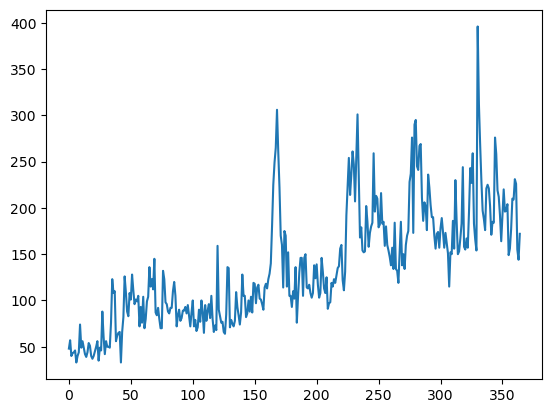

In [ ]:
subs.plot()

False

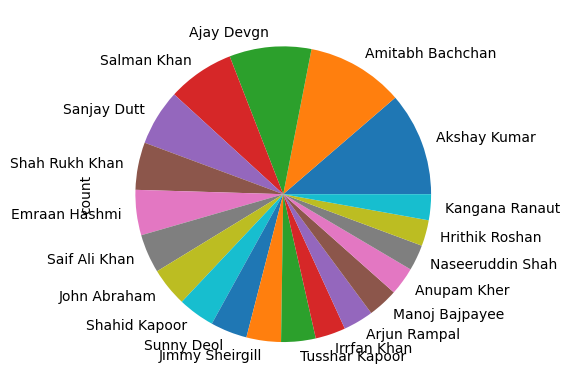

In [ ]:
movies.value_counts().head(20).plot(kind="pie")

## ----- Supplementary class  ------
### Some Important Series Methods  



In [ ]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy

In [241]:
import numpy as np
import pandas as pd

In [242]:
subs = pd.read_csv("./content/datasets-session-16/subs.csv").squeeze()
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64

In [243]:
vk = pd.read_csv(
    "./content/datasets-session-16/kohli_ipl.csv", index_col="match_no"
).squeeze()
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [244]:
movies = pd.read_csv(
    "./content/datasets-session-16/bollywood.csv", index_col="movie"
).squeeze()
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

In [245]:
# astype
import sys

sys.getsizeof(vk)  # gives the size of the series in bytes

3472

In [247]:
sys.getsizeof(vk.astype("int16"))   # series.astype() method is used to convert the data type of the series to the specified data type, in this case we are converting the data type of the series to int16 which will reduce the size of the series in bytes because int16 takes less memory than int64 which is the default data type of the series.

2182

In [248]:
# between
vk[vk.between(51, 99)].size  ## vk.between(x,y) return a boolean series where each value indicates whether the corresponding value in the original series is between x and y (inclusive) or not, and then we are using this boolean series to filter the original series and get the size of the filtered series which gives us the number of values in the original series that are between x and y (inclusive). 

43

In [ ]:
# clip
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64

In [ ]:
subs.clip(100, 200)  ## subs.clip(lower, upper) method is used to clip the values in the series to the specified lower and upper bounds, it returns a new series with the values clipped to the specified bounds, if a value is less than the lower bound then it will be replaced with the lower bound and if a value is greater than the upper bound then it will be replaced with the upper bound, if a value is within the bounds then it will remain unchanged.

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64

In [250]:
# drop_duplicates
temp = pd.Series([1, 1, 2, 2, 3, 3, 4, 4])
temp

0    1
1    1
2    2
3    2
4    3
5    3
6    4
7    4
dtype: int64

In [251]:
print(temp.drop_duplicates())
print(temp.drop_duplicates(keep="last")) ## temp.drop_duplicates(keep="last") method is used to drop the duplicate values in the series, it returns a new series with the duplicate values dropped, we can specify which duplicate value to keep by passing the argument keep="first" or "last" or False, if we pass keep="first" then it will keep the first occurrence of the duplicate value and drop the rest, if we pass keep="last" then it will keep the last occurrence of the duplicate value and drop the rest, if we pass keep=False then it will drop all the occurrences of the duplicate value.

0    1
2    2
4    3
6    4
dtype: int64
1    1
3    2
5    3
7    4
dtype: int64


In [252]:
temp.duplicated() ## duplicated() method is used to check for duplicate values in the series, it returns a boolean series where each value indicates whether the corresponding value in the original series is a duplicate or not, and then we are using this boolean series to filter the original series and get the size of the filtered series which gives us the number of duplicate values in the original series.

0    False
1     True
2    False
3     True
4    False
5     True
6    False
7     True
dtype: bool

In [ ]:
vk.duplicated().sum() ## returns the number of duplicate values in the series, it returns a single value which is the number of duplicate values in the series.

137

In [257]:
movies.drop_duplicates()

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 566, dtype: object

In [256]:
temp = pd.Series([1, 2, 3, np.nan, 5, 6, np.nan, 8, np.nan, 10])
temp

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64

In [ ]:
temp.size ## also counts the null values in the series, it returns a single value which is the total number of values in the series including null values.

10

In [ ]:
temp.count() ## only non-null values are counted, it returns a single value which is the total number of non-null values in the series.

7

In [ ]:
# isnull
temp.isnull() ## isnull() method is used to check for null values in the series, it returns a boolean series where each value indicates whether the corresponding value in the original series is null or not, and then we are using this boolean series to filter the original series and get the size of the filtered series which gives us the number of null values in the original series.

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8     True
9    False
dtype: bool

In [ ]:
temp.isnull().sum() ## total number of null values in the series, it returns a single value which is the total number of null values in the series.

3

In [ ]:
# dropna
temp.dropna() ## dropna() method is used to drop the null values in the series, it returns a new series with the null values dropped, we can specify whether to drop the null values from the index or from the values by passing the argument axis=0 or axis=1 respectively, if we pass axis=0 then it will drop the null values from the index and if we pass axis=1 then it will drop the null values from the values.

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64

In [ ]:
# fillna
temp.fillna(temp.mean()) ## fillna() method is used to fill the null values in the series with the specified value, it returns a new series with the null values filled with the specified value, we can specify the value to fill the null values with by passing the argument value=specified_value, if we pass value=temp.mean() then it will fill the null values with the mean of the series.

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

In [259]:
# isin
vk[(vk == 49) | (vk == 99)]

match_no
82    99
86    49
Name: runs, dtype: int64

##### For boolean indexing in NumPy and Pandas, you must use the bitwise operators & (AND) and | (OR). The standard Python keywords and and or will throw a ValueError because they try to evaluate the truth value of the entire array/Series at once rather than doing it element-wise. 
 - **Two strict rules apply when combining conditions:**
    - Always wrap each condition in parentheses (). Bitwise operators have a higher evaluation precedence than comparison operators (like >, <), which will break your logic without parentheses.
    - Use & for AND operations and | for OR operations

In [ ]:
vk[vk.isin([49, 99])]

match_no
82    99
86    49
Name: runs, dtype: int64

In [ ]:
# apply
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

In [ ]:
movies.apply(lambda x: x.split()[0].upper()) ## movies.apply() method is used to apply a function to each value in the series, it returns a new series with the values transformed by the function, we can specify the function to apply by passing the argument func=function_name, if we pass func=lambda x: x.split()[0].upper() then it will apply the lambda function to each value in the series which will split the value by space and take the first word and convert it to uppercase.

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: object

In [ ]:
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained Per Day, Length: 365, dtype: int64

In [ ]:
subs.apply(lambda x: "good day" if x > subs.mean() else "bad day")

0       bad day
1       bad day
2       bad day
3       bad day
4       bad day
         ...   
360    good day
361    good day
362    good day
363    good day
364    good day
Name: Subscribers gained Per Day, Length: 365, dtype: object

In [ ]:
subs.mean()

135.64383561643837

In [ ]:
# copy

In [ ]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [ ]:
new = (
    vk.head()
)  # retunns a view of the original series, so any changes made to the new series will be reflected in the original series as well

In [ ]:
new

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [ ]:
new[1] = 1

In [ ]:
new = vk.head().copy()

In [ ]:
new[1] = 100

In [ ]:
new

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64

In [ ]:
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

# Comparing View and Copy in Pandas (Using Series)

Moving on! Understanding how data is accessed in Pandas is crucial for effective data manipulation. The two primary methods used are **view** and **copy**. Let's dig deeper.

---

# What is View in Pandas?

When you create a **view** of a Series in Pandas, it references the **same data in memory**. That means any changes made in the view are reflected in the original Series.

### Example

```python
import pandas as pd

# Original Series
marks = pd.Series([10, 20, 30, 40])

# Creating a view using slicing
view_marks = marks[1:4]

# Modifying the view
view_marks.iloc[0] = 99

print("Original Series:")
print(marks)

print("\nView:")
print(view_marks)
```

### Output

```
Original Series:
0    10
1    99
2    30
3    40
dtype: int64

View:
1    99
2    30
3    40
dtype: int64
```

The value at index `1` in the original Series becomes `99`, showing that both `marks` and `view_marks` share the same underlying data.

---

# Why Does Pandas Return a View?

A view does **not create new memory**. Instead, it points to the existing data.

### Advantages

- Faster operation.
- Requires less memory.
- Useful when you want changes to affect the original data.

Think of a view as another window looking at the same object.

```
marks
   ↓
[10, 20, 30, 40]
   ↑
view_marks
```

---

# What is Copy in Pandas?

When you create a copy of a Series, Pandas creates a **completely separate object in memory**. Changes made to the copy do not affect the original Series.

### Example

```python
import pandas as pd

# Original Series
marks = pd.Series([10, 20, 30, 40])

# Creating a copy
copy_marks = marks.copy()

# Modifying the copy
copy_marks.iloc[0] = 99

print("Original Series:")
print(marks)

print("\nCopy:")
print(copy_marks)
```

### Output

```
Original Series:
0    10
1    20
2    30
3    40
dtype: int64

Copy:
0    99
1    20
2    30
3    40
dtype: int64
```

Here, changing `copy_marks` does not affect `marks`.

---

# Why Does Pandas Return a Copy?

A copy allocates **new memory** and stores independent data.

### Advantages

- Protects the original data.
- Safer for experimentation and analysis.
- Prevents accidental modifications.

Think of a copy as making a photocopy of a document.

```
marks ----------> [10, 20, 30, 40]

copy_marks -----> [10, 20, 30, 40]
```

Both objects have separate memory.

---

# Why Does Pandas Sometimes Return a View and Sometimes a Copy?

Pandas tries to balance:

1. **Performance**
   - Reusing existing memory (view) is faster.

2. **Safety**
   - Creating new memory (copy) avoids unintended changes.

Because of this, the returned object depends on the operation being performed.

### Operations that often return a View

```python
view_marks = marks[1:4]
```

Slicing usually shares memory with the original object.

---

### Operations that often return a Copy

```python
copy_marks = marks[[1, 3]]
```

or

```python
copy_marks = marks.copy()
```

These operations generally create a new object with separate memory.

---

# Precautions with Views and Copies

Since it is not always obvious whether Pandas has returned a view or a copy, unexpected results may occur.

### Recommended Practice

If you want independent data, explicitly create a copy:

```python
new_marks = marks.copy()
```

This avoids accidental changes to the original Series.

---

# When to Use View?

Use a view when:

- You want to work with the original data.
- Changes should be reflected in the original Series.
- You want better memory efficiency.

---

# When to Use Copy?

Use a copy when:

- You are experimenting with data.
- You do not want to modify the original Series.
- You want safer and more predictable behavior.

---

# Summary

| Feature                  | View            | Copy                        |
| ------------------------ | --------------- | --------------------------- |
| Memory                   | Shared          | Separate                    |
| Changes affect original? | Yes             | No                          |
| Speed                    | Faster          | Slower                      |
| Memory usage             | Less            | More                        |
| Safe for experimentation | No              | Yes                         |
| Created by               | Usually slicing | `.copy()` or fancy indexing |

---

## Memory Illustration

### View

```
marks
  ↓
[10, 20, 30, 40]
  ↑
view_marks
```

Both objects point to the same memory.

### Copy

```
marks ------> [10, 20, 30, 40]

copy_marks -> [10, 20, 30, 40]
```

Each object has its own memory, so changes in one do not affect the other.
